# Volatility Forecasting using ARIMA–GARCH Models

### Objective:
### Model the conditional mean and conditional variance of returns and compare volatility forecasts from EGARCH, GARCH-t and GJR-GARCH models.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller , acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
import statsmodels.api as sm

In [2]:
# Suppress ValueWarning from statsmodels regarding frequency
warnings.simplefilter('ignore', ValueWarning)

In [3]:
#!pip install arch

In [4]:
df= pd.read_excel(r"C:\Users\mankw\OneDrive\Documents\2026\MFE\Applied Economics and Machine learning\code\Book1.xlsx")
df.head()

,Exchange Date,Close
0,2026-01-30,102.9
1,2026-01-29,103.5
2,2026-01-28,102.9
3,2026-01-27,102.4
4,2026-01-26,104.1


In [5]:
df["return"] = np.log(df["Close"]/df["Close"].shift(1))
df.dropna(inplace = True) # or df = df.dropna()
rt = df["return"]
df.head()

,Exchange Date,Close,return
1,2026-01-29,103.5,0.005814
2,2026-01-28,102.9,-0.005814
3,2026-01-27,102.4,-0.004871
4,2026-01-26,104.1,0.016465
5,2026-01-23,105.5,0.013359


In [6]:
df['Exchange Date'] = pd.to_datetime(df['Exchange Date'])  # Convert 'Date' to datetime if it isn't already
df = df.set_index('Exchange Date') 
df.head()

,Close,return
Exchange Date,,
2026-01-29,103.5,0.005814
2026-01-28,102.9,-0.005814
2026-01-27,102.4,-0.004871
2026-01-26,104.1,0.016465
2026-01-23,105.5,0.013359


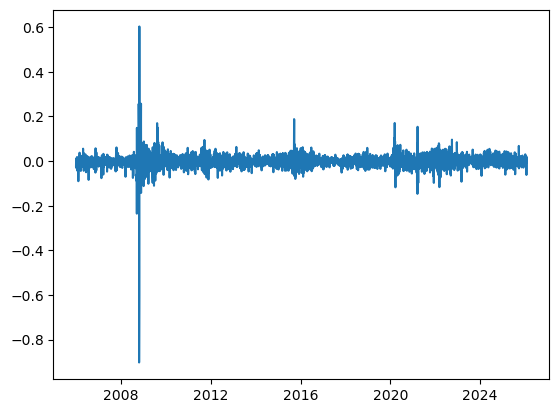

In [7]:
plt.plot(df["return"])

In [8]:
#?adfuller

### checking for Stationarity
####  using adftller Test 
#### H0 : returns are not  stationary  
#### Ha : returns are stationary 

In [9]:

result = adfuller(df["return"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Used lags:", result[2])
print("Number of observations:", result[3])
print("Critical values:")
for key, value in result[4].items():
    print(f" {key}: {value}")


ADF Statistic: -13.579997930190787
p-value: 2.1329397993504894e-25
Used lags: 27
Number of observations: 5069
Critical values:
 1%: -3.431640711105285
 5%: -2.8621103564473316
 10%: -2.567073601134877


### since P value is less than 0.5 , There is insufficient Evidence to reject HO:
### therefore , we are 95 % confident that the returns are stationary 

## ACF TEST
## to help us to pick appropriate ARIMA model 

In [10]:
#acf(rt)

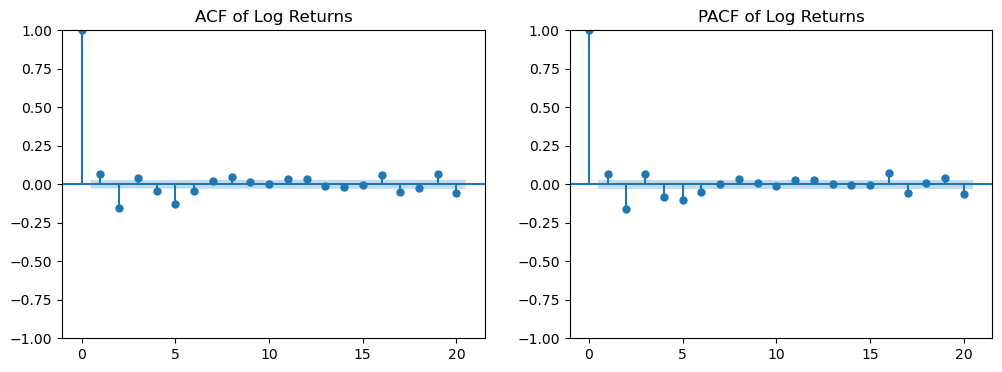

In [11]:

# Plot ACF and PACF for log returns
fig, axes = plt.subplots(1, 2,figsize=(12,4))

plot_acf(df["return"], lags=20, ax=axes[0])
axes[0].set_title("ACF of Log Returns")

plot_pacf(df["return"], lags=20, ax=axes[1])
axes[1].set_title("PACF of Log Returns")

plt.show()


## Test for Autocorrelation using Ljung- box Test 
### we want to confirm whether the atocorrelation is statistically significant 

In [12]:
ljun = acorr_ljungbox( df["return"] , lags = [10] , return_df = True)
print(ljun)

       lb_stat     lb_pvalue
10  269.596375  4.068162e-52


### since P value is less than 0.50, we reject the H0 , there is sufficient evidence to reject H0 at5 % significant level 
### Therefore we 95 %  confident that there autocorrelation is statistically significant 

#  Fit Model 

In [13]:
## we pick  ARIMA(1,1) is the best

In [14]:
# MOdel 

In [15]:
model = ARIMA(df["return"],order =(1,0,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 return   No. Observations:                 5097
Model:                 ARIMA(1, 0, 1)   Log Likelihood               10876.732
Date:                Wed, 11 Mar 2026   AIC                         -21745.464
Time:                        16:11:00   BIC                         -21719.319
Sample:                             0   HQIC                        -21736.310
                               - 5097                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.000     -0.369      0.712      -0.001       0.001
ar.L1         -0.5501      0.024    -22.804      0.000      -0.597      -0.503
ma.L1          0.6830      0.024     27.922      0.0

Interpretation of ARIMA(1,0,1) Results:
----------------------------------------
1. Coefficients & Significance:
   - AR(1) term  is statistically significant (p < 0.05).
     Current returns are negatively vely correlated with the previous day's return.
   - MA(1) term is statistically significant (p < 0.05).
     The model significantly uses the previous forecast error to correct the current prediction.
   - Constant term  is NOT significant.
     The mean daily return is not statistically different from zero.

2. Residual Diagnostics:
   - Ljung-Box Test (p value < 0.05): Reject null.
     Significant autocorrelation remains in the residuals.
   - Jarque-Bera Test (p=value < 0.05): Reject null.
     The residuals are NOT normally distributed. They likely have 'fat tails'.as well as kurtosis is > 3 
     This suggests that while the mean is modeled well, the volatility (risk) might change over time (GARCH effects).

#### residuals still contain autocorrelation,
### the ARIMA(1,0,1) model is not adequate, so we try alternative ARIMA specifications and compare them using AIC/BIC.

In [16]:
# Alternative ARIMA orders to test
alt = [(1,0,1), (2,0,1), (1,0,2), (2,0,2)]

results_list = []

best_aic = float('inf')
best_order = None
best_model_fit = None

for i in alt:
    try:
        model_alt = ARIMA( df["return"], order=i)
        model_alt_fit = model_alt.fit()

        aic = model_alt_fit.aic
        bic = model_alt_fit.bic

        results_list.append({
            'Order': i,
            'AIC': aic,
            'BIC': bic
        })

        if aic < best_aic:
            best_aic = aic
            best_order = i
            best_model_fit = model_alt_fit

    except Exception as e:
        print(f"Model {i} failed: {e}")

print("-" * 50)
print(f"Best model based on AIC: ARIMA{best_order}")

print("\nSummary of Best Model:")
print(best_model_fit.summary())

--------------------------------------------------
Best model based on AIC: ARIMA(2, 0, 2)

Summary of Best Model:
                               SARIMAX Results                                
Dep. Variable:                 return   No. Observations:                 5097
Model:                 ARIMA(2, 0, 2)   Log Likelihood               10913.303
Date:                Wed, 11 Mar 2026   AIC                         -21814.605
Time:                        16:11:13   BIC                         -21775.387
Sample:                             0   HQIC                        -21800.873
                               - 5097                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.000     -0.436      0.663      -0.001       0.001
ar.L1          0

Interpretation of ARIMA(2,0,2) Results:
----------------------------------------
1. Coefficients & Significance:
   - AR(1) term  is statistically significant (p < 0.05).
     Current returns are + correlated with the previous day's return.
   - MA(1) term is statistically significant (p < 0.05).
     The model significantly uses the previous forecast error to correct the current prediction.
   - Constant term  is NOT significant.
     The mean daily return is not statistically different from zero.

2. Residual Diagnostics:
   - Ljung-Box Test (p value > 0.05):Fail to Reject null.
     there is no autocorrelation remains in the residuals.
   - Jarque-Bera Test (p=value < 0.05): Reject null.
     The residuals are NOT normally distributed. They likely have 'fat tails'.as well as kurtosis is > 3 
     This suggests that while the mean is modeled well, the volatility (risk) might change over time (GARCH effects).

### since ARIMA(2,0,2) is adequate now we can move to forecasting 

# FORECAST 

In [17]:
print(rt)

1       0.005814
2      -0.005814
3      -0.004871
4       0.016465
5       0.013359
          ...   
5093   -0.010311
5094   -0.003092
5095    0.010780
5096    0.008715
5097   -0.021931
Name: return, Length: 5097, dtype: float64


C:\Users\mankw\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


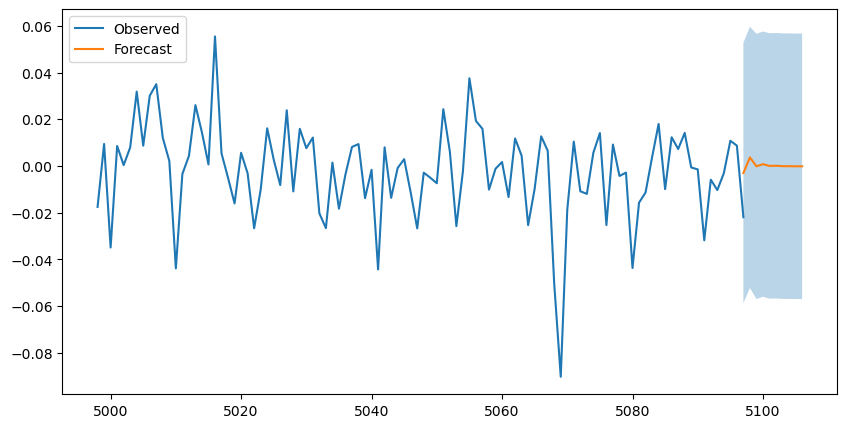

In [18]:
# Forecast the next 10 periods
forecast = best_model_fit.forecast(steps=10)
forecast_res = best_model_fit.get_forecast(steps=10)
forecast_mean = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int()

plt.figure(figsize=(10,5))
plt.plot(rt.dropna().iloc[-100:], label="Observed")
plt.plot(forecast_mean.index, forecast_mean, label="Forecast")

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.3
)
plt.legend()
plt.show()

# Testing ArchEffects 


In [19]:

resid = model_fit.resid

arch_test = het_arch(resid)

print(arch_test)

(np.float64(2331.19404635925), np.float64(0.0), 429.38948454213755, 0.0)


#### There is garch efects ,ARCH effects are present (there is sufficinet evidence to reject Null Hypothesis). Volatility is not constant

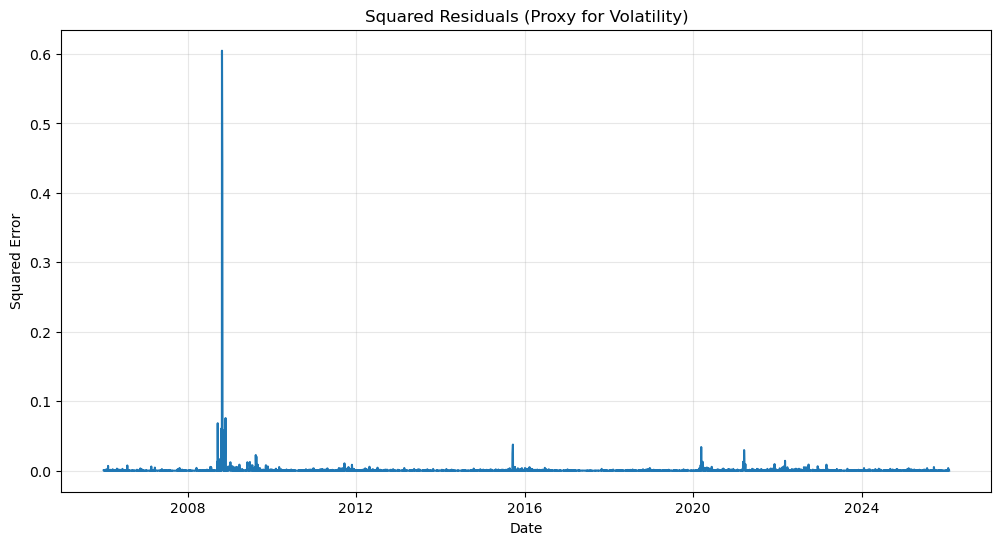

In [20]:
#Plot Squared Residuals to visualize volatility clustering
plt.figure(figsize=(12, 6))
plt.plot(model_fit.resid**2)
plt.title('Squared Residuals (Proxy for Volatility)')
plt.xlabel('Date')
plt.ylabel('Squared Error')
plt.grid(True, alpha=0.3)
plt.show()

Fitting GARCH(1,1) model...
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                12717.2
Distribution:                  Normal   AIC:                          -25426.3
Method:            Maximum Likelihood   BIC:                          -25400.2
                                        No. Observations:                 5097
Date:                Wed, Mar 11 2026   Df Residuals:                     5096
Time:                        16:11:15   Df Model:                            1
                                   Mean Model                                  
                  coef    std err          t      P>|t|        95.0% Conf. Int.
-------------------------------------------------------------------------------
mu         -8.0105e-0

C:\Users\mankw\.julia\conda\3\x86_64\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0008411. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


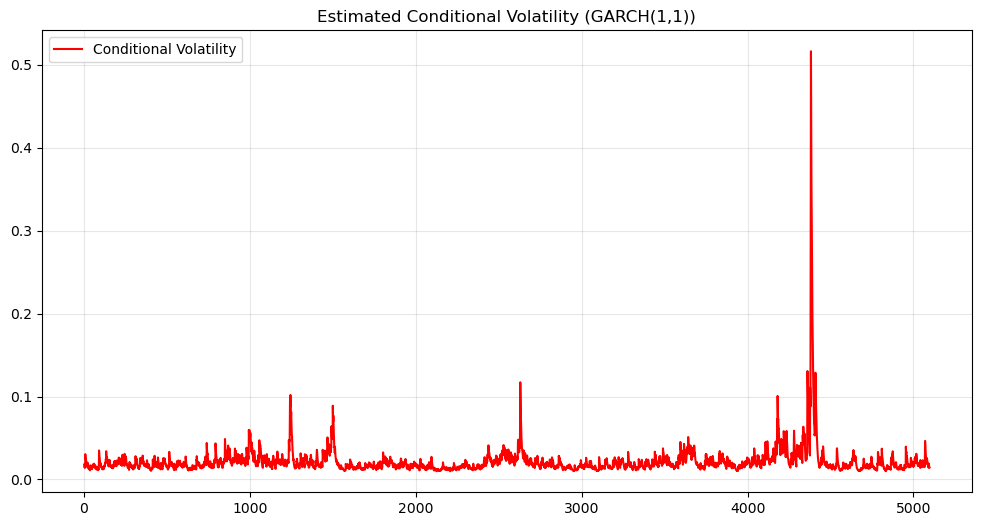

In [21]:

# --- Step 1: Fit GARCH(1,1) Model ---
# We use the 'Garch' volatility model with p=1 (lagged variance) and q=1 (lagged residual)
print("Fitting GARCH(1,1) model...")
am = arch_model(rt, vol='Garch', p=1, q=1)
garch_result = am.fit(disp='off')

# Display the summary
print(garch_result.summary())

# --- Step 2: Visualizing Conditional Volatility ---
# This shows how the estimated risk (standard deviation) changes over time
plt.figure(figsize=(12, 6))
plt.plot(garch_result.conditional_volatility, color='red', label='Conditional Volatility')
plt.title('Estimated Conditional Volatility (GARCH(1,1))')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Step 3: Interpretation ---
params = garch_result.params
alpha = params['alpha[1]']
beta = params['beta[1]']
sum_coeffs = alpha + beta


In [22]:
#self._check_scale(resids)

# Rescalling returns 

Fitting GARCH(1,1) model...
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -10723.1
Distribution:                  Normal   AIC:                           21454.2
Method:            Maximum Likelihood   BIC:                           21480.3
                                        No. Observations:                 5097
Date:                Wed, Mar 11 2026   Df Residuals:                     5096
Time:                        16:11:15   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu            -0.0699  2.573e-02 

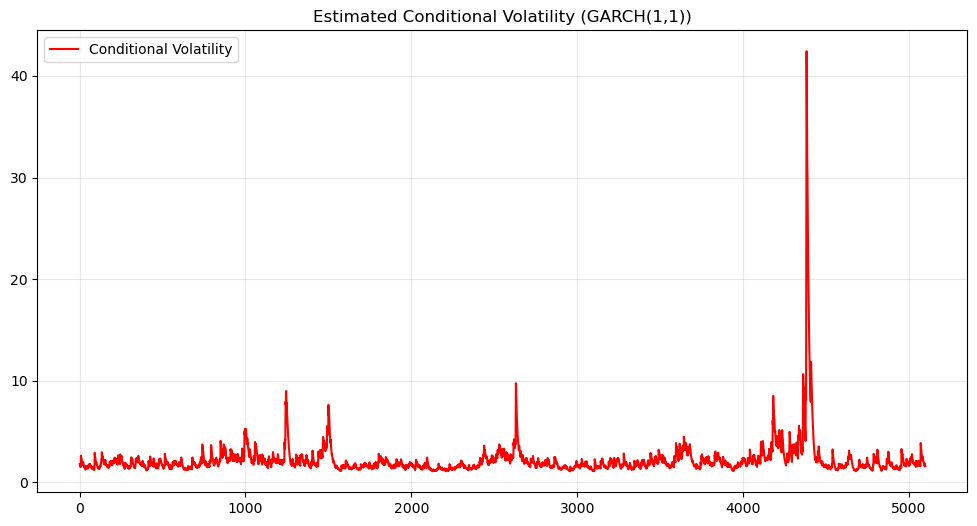

In [23]:

# --- Step 1: Fit GARCH(1,1) Model ---
# We use the 'Garch' volatility model with p=1 (lagged variance) and q=1 (lagged residual)
print("Fitting GARCH(1,1) model...")
am = arch_model(rt*100, vol='Garch', p=1, q=1)
garch_result = am.fit(disp='off')

# Display the summary
print(garch_result.summary())

# --- Step 2: Visualizing Conditional Volatility ---
# This shows how the estimated risk (standard deviation) changes over time
plt.figure(figsize=(12, 6))
plt.plot(garch_result.conditional_volatility, color='red', label='Conditional Volatility')
plt.title('Estimated Conditional Volatility (GARCH(1,1))')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Step 3: Interpretation ---
params = garch_result.params
alpha = params['alpha[1]']
beta = params['beta[1]']
sum_coeffs = alpha + beta


### Interpretation of GARCH(1,1)

- The mean return is **negative and significant** (\(\mu = -0.0699,\; p = 0.0066\)).
- The **ARCH effect** is significant (\(\alpha_1 = 0.1271,\; p < 0.001\)), meaning volatility reacts to recent shocks.
- The **GARCH effect** is significant and large (\(\beta_1 = 0.8533,\; p < 0.001\)), showing volatility is highly persistent.
- Since \(\alpha_1 + \beta_1 = 0.9804\), volatility is **very persistent** and shows **volatility clustering**.
- Overall, the model confirms **time-varying volatility** in returns.

# Fit & Forecast Specific Models

## Divde data into training and Test

In [24]:
n = len(df["return"])
split_idx = int(0.8 * n)

train = df["return"].iloc[:split_idx]
test = df["return"].iloc[split_idx:]

In [25]:
print("Total observations:", n)
print("Split index:", split_idx)
print("Training size:", len(train))
print("Test size:", len(test))

Total observations: 5097
Split index: 4077
Training size: 4077
Test size: 1020


## fit Model 

In [26]:
mean_model = ARIMA(train, order=(2,0,2))
mean_fit = mean_model.fit()

print(mean_fit.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7.957e-05      0.000     -0.238      0.812      -0.001       0.001
ar.L1         -1.5558      0.148    -10.508      0.000      -1.846      -1.266
ar.L2         -0.6378      0.106     -6.002      0.000      -0.846      -0.430
ma.L1          1.5961      0.148     10.804      0.000       1.307       1.886
ma.L2          0.6747      0.107      6.277      0.000       0.464       0.885
sigma2         0.0004   4.32e-06     99.582      0.000       0.000       0.000


## Filter the Full Dataset Using Training Parameters

In [27]:
full_mean_model = ARIMA(df["return"], order=(2, 0, 2))
mean_res_full = full_mean_model.filter(mean_fit.params)
residuals = mean_res_full.resid

## Fit Volatility Models on Residuals

In [28]:
am_egarch = arch_model(residuals*100, mean='Zero', vol='EGARCH', p=1, q=1, dist='Normal')
am_garch_t = arch_model(residuals*100, mean='Zero', vol='Garch', p=1, q=1, dist='t')
am_gjr_skewt = arch_model(residuals*100, mean='Zero', vol='Garch', p=1, o=1, q=1, dist='skewt')

## Fit These Models on the Training Portion Only

In [29]:
res_egarch = am_egarch.fit(last_obs=split_idx, disp='off')
res_garch_t = am_garch_t.fit(last_obs=split_idx, disp='off')
res_gjr_skewt = am_gjr_skewt.fit(last_obs=split_idx, disp='off')

## Forecasting 10 Steps Ahead

In [30]:
forecasts_egarch = res_egarch.forecast(start=split_idx, horizon=10, method='simulation')
forecasts_garch_t = res_garch_t.forecast(start=split_idx, horizon=10, method='simulation')
forecasts_gjr_skewt = res_gjr_skewt.forecast(start=split_idx, horizon=10, method='simulation')

## Extract the h=10 Variance Forecast

In [31]:
var_egarch = forecasts_egarch.variance['h.10']
var_garch_t = forecasts_garch_t.variance['h.10']
var_gjr_skewt = forecasts_gjr_skewt.variance['h.10']

## Align Forecasts with Realizations

In [44]:
comparison = pd.DataFrame({
    'True_Proxy': df["return"]** 2,
    'EGARCH': var_egarch.shift(10)/1000,
    'GARCH_t': var_garch_t.shift(10)/1000,
    'GJR_Skewt': var_gjr_skewt.shift(10)/1000
})

In [46]:
comparison = comparison.dropna(axis =0 )
comparison.head()

,True_Proxy,EGARCH,GARCH_t,GJR_Skewt
Exchange Date,,,,
2006-01-02,0.000481,0.004123,0.003968,0.004672
2006-01-03,0.000076,0.004439,0.004372,0.005187
2006-01-04,0.000116,0.004490,0.004374,0.005260
2006-01-05,0.000010,0.004600,0.004658,0.005417
2006-01-06,0.000106,0.004740,0.004704,0.005777


## Compute Forecast Accuracy Metrics

In [52]:
models = ['EGARCH', 'GARCH_t', 'GJR_Skewt']
errors_sq = pd.DataFrame(index=comparison.index)
errors_abs = pd.DataFrame(index=comparison.index)

# Proxy is 'True_Proxy' (Squared Returns)
actual = comparison['True_Proxy']

In [56]:
for m in models:
    mse = ((comparison[m] - comparison['True_Proxy'])**2).mean()
    mae = (comparison[m] - comparison['True_Proxy']).abs().mean()

# Calculate and Display MSE and MAE
mse = errors_sq.mean()
mae = errors_abs.mean()


In [58]:
metrics = {}

for m in ['EGARCH', 'GARCH_t', 'GJR_Skewt']:
    mse = ((comparison[m] - comparison['True_Proxy'])**2).mean()
    mae = (comparison[m] - comparison['True_Proxy']).abs().mean()
    metrics[m] = {'MSE': mse, 'MAE': mae}

metrics_df = pd.DataFrame(metrics).T

print("Forecast Accuracy Metrics (Test Set - 10 Steps Ahead):")
print(metrics_df)

best_mse_model = metrics_df['MSE'].idxmin()
best_mae_model = metrics_df['MAE'].idxmin()

print(f"\nBest Model by MSE: {best_mse_model}")
print(f"Best Model by MAE: {best_mae_model}")

Forecast Accuracy Metrics (Test Set - 10 Steps Ahead):
                MSE       MAE
EGARCH     0.001195  0.008700
GARCH_t    0.005750  0.017242
GJR_Skewt  0.007758  0.019377

Best Model by MSE: EGARCH
Best Model by MAE: EGARCH


## The DM test checks whether forecast accuracy differs significantly between models.

In [59]:
def dm_test(actual, pred1, pred2, h=10):
    e1 = (actual - pred1)**2
    e2 = (actual - pred2)**2
    d = e1 - e2
    res = sm.OLS(d, np.ones_like(d)).fit(cov_type='HAC', cov_kwds={'maxlags': h})
    return res.tvalues.iloc[0], res.pvalues.iloc[0]

In [60]:

pairs = [('EGARCH', 'GARCH_t'), ('EGARCH', 'GJR_Skewt'), ('GARCH_t', 'GJR_Skewt')]
for m1, m2 in pairs:
    stat, pval = dm_test(comparison['True_Proxy'], comparison[m1], comparison[m2], h=10)
    print(f"{m1} vs {m2}: DM={stat:.4f}, p={pval:.4f} [{'Diff' if pval<0.05 else 'Same'}]")

EGARCH vs GARCH_t: DM=-1.3248, p=0.1852 [Same]
EGARCH vs GJR_Skewt: DM=-1.3376, p=0.1810 [Same]
GARCH_t vs GJR_Skewt: DM=-1.3647, p=0.1724 [Same]


## conclusion 

### EGARCH achieved the lowest MSE and MAE, making it the preferred model in practical terms, although the Diebold-Mariano tests indicate that the differences in predictive accuracy are not statistically significant.

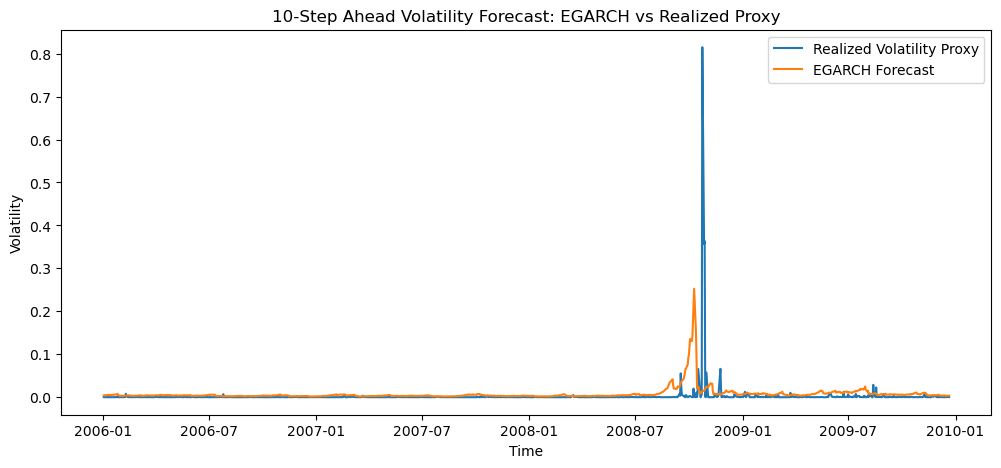

In [61]:

plt.figure(figsize=(12,5))
plt.plot(comparison.index, comparison['True_Proxy'], label='Realized Volatility Proxy')
plt.plot(comparison.index, comparison['EGARCH'], label='EGARCH Forecast')

plt.title('10-Step Ahead Volatility Forecast: EGARCH vs Realized Proxy')
plt.xlabel('Time')
plt.ylabel('Volatility')
plt.legend()
plt.show()

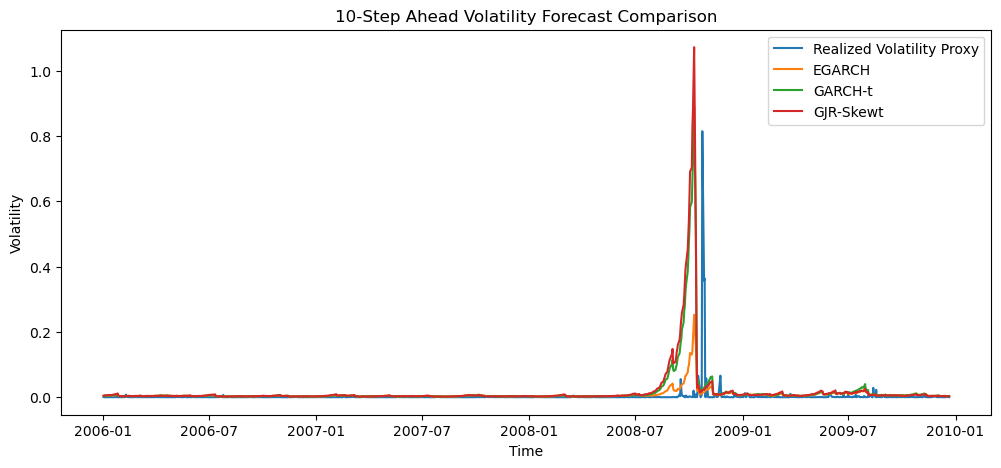

In [62]:

plt.figure(figsize=(12,5))
plt.plot(comparison.index, comparison['True_Proxy'], label='Realized Volatility Proxy')
plt.plot(comparison.index, comparison['EGARCH'], label='EGARCH')
plt.plot(comparison.index, comparison['GARCH_t'], label='GARCH-t')
plt.plot(comparison.index, comparison['GJR_Skewt'], label='GJR-Skewt')

plt.title('10-Step Ahead Volatility Forecast Comparison')
plt.xlabel('Time')
plt.ylabel('Volatility')
plt.legend()
plt.show()

### Conclusion

#### The ARIMA(2,0,2) model was used to filter the conditional mean of returns.
#### Three volatility models (EGARCH, GARCH-t, and GJR-GARCH-Skewt) were estimated on the residuals.
#### Forecast evaluation using MSE and MAE indicates that the EGARCH model provides the most accurate 10-step-ahead volatility forecasts.
#### However, Diebold–Mariano tests suggest that the differences in predictive accuracy between models are not statistically significant.